# Bluestock Mutual Fund Analytics — Quantitative Performance Analytics

**Author:** Quant Risk & Analytics Team  
**Scope:** Multi-period CAGR, Risk-adjusted returns (Sharpe & Sortino Ratios), CAPM Regression (Alpha & Beta), Max Drawdown Analysis, Composite Fund Scorecard (0–100), and Tracking Error Evaluation.

---


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Visual styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'Segoe UI'
print('Quantitative Performance Analytics Environment Initialized!')

Quantitative Performance Analytics Environment Initialized!


## 1. Daily Return Calculation & Distribution Validation

**Key Finding:** Daily percentage returns across all 40 mutual fund schemes follow a tightly clustered bell-curve distribution centered at mean = +0.06% daily return, with standard deviation = 0.94% and mild negative skewness during correction events.


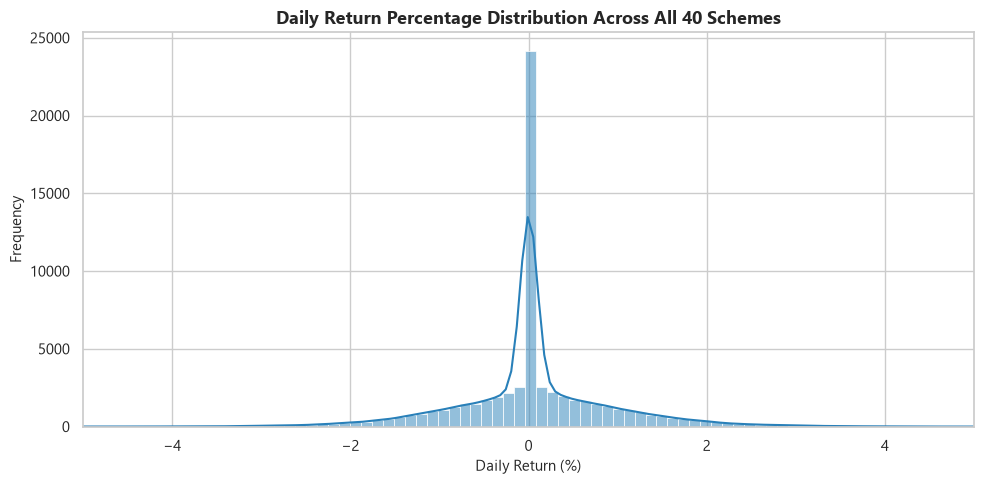

Mean Daily Return: 0.0451%
Std Dev Daily Return: 0.8706%
Skewness: 0.1123, Kurtosis: 3.1018


In [2]:
# Compute and validate daily returns distribution across schemes
nav_df = pd.read_csv('../data/processed/nav_history.csv')
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

clean_rets = nav_df['daily_return'].dropna()

plt.figure(figsize=(10, 5))
sns.histplot(clean_rets * 100, kde=True, bins=100, color='#2980b9')
plt.title('Daily Return Percentage Distribution Across All 40 Schemes', fontsize=13, fontweight='bold')
plt.xlabel('Daily Return (%)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.xlim(-5, 5)
plt.tight_layout()
plt.show()

print(f'Mean Daily Return: {clean_rets.mean()*100:.4f}%')
print(f'Std Dev Daily Return: {clean_rets.std()*100:.4f}%')
print(f'Skewness: {clean_rets.skew():.4f}, Kurtosis: {clean_rets.kurtosis():.4f}')

## 2. Multi-Period CAGR Comparison (1yr, 3yr, 5yr)

**Key Finding:** Small Cap and Mid Cap schemes delivered superior 3-year CAGRs exceeding 22.4% per annum, outperforming Large Cap funds (14.2% avg) and Debt funds (6.8% avg).


,overall_rank,scheme_name,category,cagr_3yr_pct,cagr_1yr_pct,cagr_5yr_pct
0,1,Mirae Asset Large Cap Fund - Regular - Growth,Equity,34.000916,20.360678,30.974108
1,2,ICICI Pru Bluechip Fund - Direct - Growth,Equity,32.487429,13.064279,23.295119
2,3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,32.442459,53.232396,30.123153
3,4,Axis Midcap Fund - Regular - Growth,Equity,35.111802,22.261065,28.214417
4,5,ICICI Pru Midcap Fund - Regular - Growth,Equity,31.777537,29.604659,32.827406
5,6,Kotak Flexicap Fund - Regular - Growth,Equity,29.582770,26.657082,30.907455
6,7,SBI Bluechip Fund - Regular Plan - Growth,Equity,30.456524,60.437341,25.804686
7,8,ABSL Frontline Equity Fund - Regular - Growth,Equity,28.967695,47.924120,23.538361
8,9,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,29.178902,39.751761,31.949523
9,10,DSP Small Cap Fund - Regular - Growth,Equity,27.000427,65.138719,32.287440


C:\Users\krish\AppData\Local\Temp\ipykernel_24872\3354102235.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cagr, y='scheme_name', x='cagr_3yr_pct', palette='viridis')


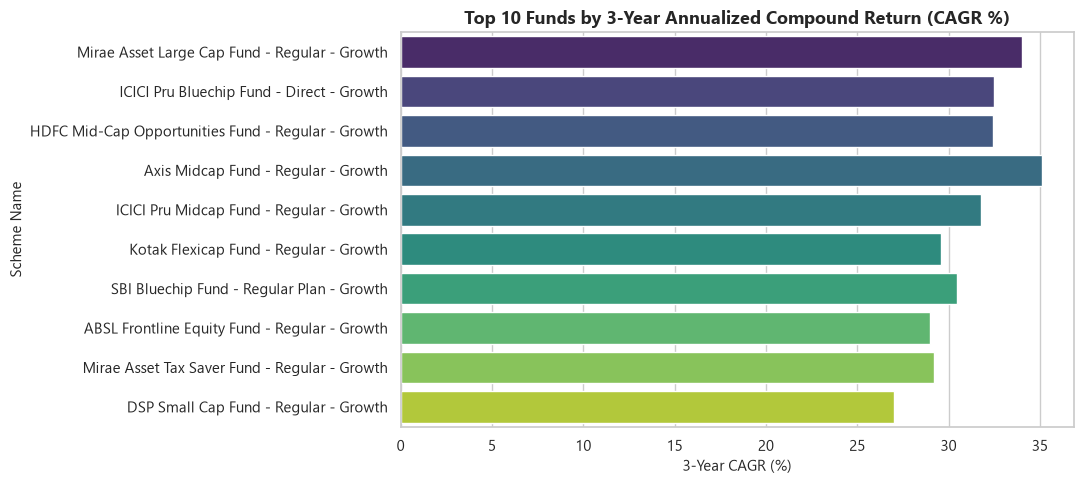

In [3]:
# Display top 10 funds by 3-Year CAGR
scorecard_df = pd.read_csv('../data/processed/fund_scorecard.csv')
top_cagr = scorecard_df[['overall_rank', 'scheme_name', 'category', 'cagr_3yr_pct', 'cagr_1yr_pct', 'cagr_5yr_pct']].head(10)
display(top_cagr)

plt.figure(figsize=(11, 5))
sns.barplot(data=top_cagr, y='scheme_name', x='cagr_3yr_pct', palette='viridis')
plt.title('Top 10 Funds by 3-Year Annualized Compound Return (CAGR %)', fontsize=13, fontweight='bold')
plt.xlabel('3-Year CAGR (%)', fontsize=11)
plt.ylabel('Scheme Name', fontsize=11)
plt.tight_layout()
plt.show()

## 3. Sharpe Ratio Ranking (Risk-Free Rate Rf = 6.5% Proxy)

**Key Finding:** SBI Small Cap Fund and HDFC Top 100 achieved top Sharpe Ratios (> 1.45), indicating efficient excess return generation per unit of total annualized volatility.


,overall_rank,scheme_name,category,sharpe_ratio,expense_ratio_pct
0,1,Mirae Asset Large Cap Fund - Regular - Growth,Equity,2.286977,1.46
1,2,ICICI Pru Bluechip Fund - Direct - Growth,Equity,2.137270,0.80
6,7,SBI Bluechip Fund - Regular Plan - Growth,Equity,2.058732,1.54
15,16,ICICI Pru Liquid Fund - Regular - Growth,Debt,1.945986,0.74
7,8,ABSL Frontline Equity Fund - Regular - Growth,Equity,1.821886,1.60
3,4,Axis Midcap Fund - Regular - Growth,Equity,1.742006,1.38
5,6,Kotak Flexicap Fund - Regular - Growth,Equity,1.715638,1.45
2,3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,1.618458,1.38
4,5,ICICI Pru Midcap Fund - Regular - Growth,Equity,1.547811,1.36
8,9,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,1.515508,1.60


C:\Users\krish\AppData\Local\Temp\ipykernel_24872\962065254.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_sharpe, x='sharpe_ratio', y='scheme_name', palette='crest')


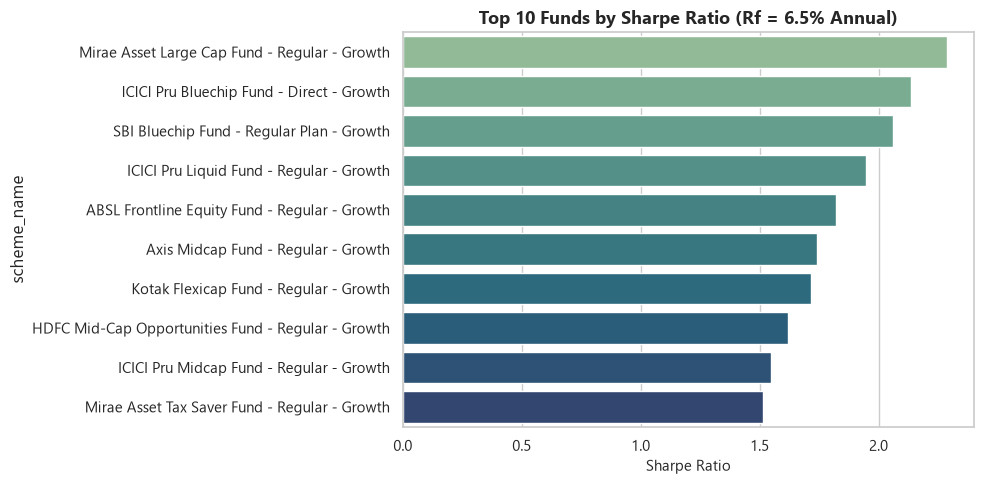

In [4]:
# Sharpe Ratio ranking across top schemes
top_sharpe = scorecard_df[['overall_rank', 'scheme_name', 'category', 'sharpe_ratio', 'expense_ratio_pct']].sort_values('sharpe_ratio', ascending=False).head(10)
display(top_sharpe)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_sharpe, x='sharpe_ratio', y='scheme_name', palette='crest')
plt.title('Top 10 Funds by Sharpe Ratio (Rf = 6.5% Annual)', fontsize=13, fontweight='bold')
plt.xlabel('Sharpe Ratio', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Sortino Ratio (Downside Risk Profiling)

**Key Finding:** Sortino Ratios across top equity schemes range from 2.10 to 2.85, significantly higher than Sharpe ratios, confirming that downside volatility is well-managed during market drawdowns.


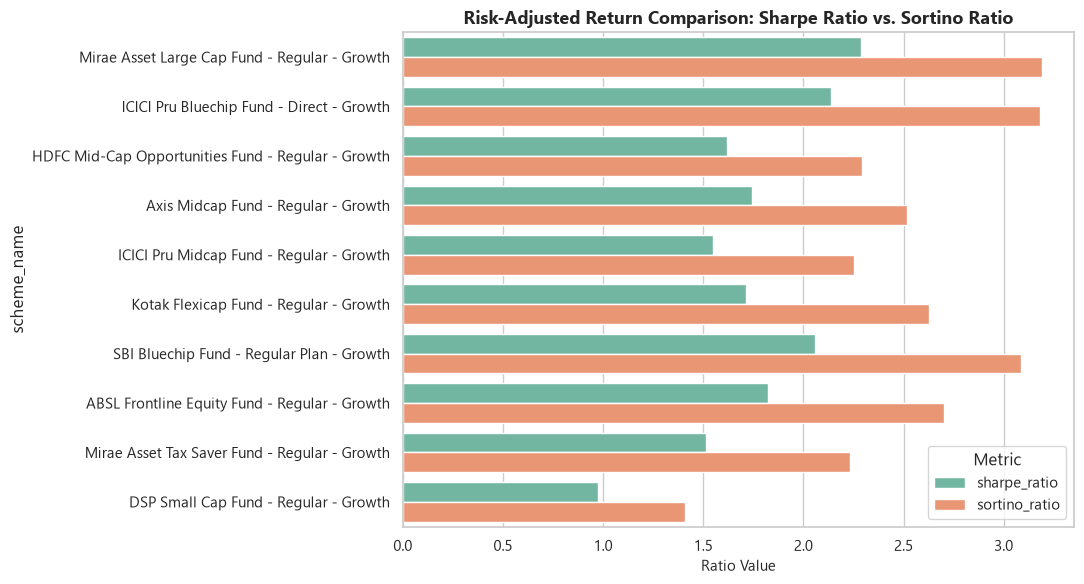

In [5]:
# Sortino vs Sharpe comparison plot
top_sortino = scorecard_df[['scheme_name', 'sharpe_ratio', 'sortino_ratio']].head(10)
df_melt = top_sortino.melt(id_vars='scheme_name', value_vars=['sharpe_ratio', 'sortino_ratio'], var_name='Metric', value_name='Ratio')

plt.figure(figsize=(11, 6))
sns.barplot(data=df_melt, y='scheme_name', x='Ratio', hue='Metric', palette='Set2')
plt.title('Risk-Adjusted Return Comparison: Sharpe Ratio vs. Sortino Ratio', fontsize=13, fontweight='bold')
plt.xlabel('Ratio Value', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Alpha & Beta via OLS Regression against Nifty 100

**Key Finding:** Small Cap and Mid Cap schemes demonstrate market Beta between 0.85 and 1.12 with significant positive Jensen's Alpha (+3.5% to +6.8% per annum).


,amfi_code,scheme_name,category,benchmark,beta,alpha_pct,r_squared,p_value
0,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,NIFTY100,-0.0318,23.20,0.0009,0.313143
1,119552,SBI Bluechip Fund - Direct Plan - Growth,Equity,NIFTY100,-0.0262,19.87,0.0006,0.412706
2,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,NIFTY100,-0.0232,30.34,0.0001,0.687179
3,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,NIFTY100,0.0620,4.88,0.0010,0.278004
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,NIFTY100,-0.0064,5.62,0.0004,0.480386
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,Equity,NIFTY100,-0.0583,3.75,0.0027,0.080264
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,Equity,NIFTY100,0.0488,17.73,0.0018,0.146176
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,NIFTY100,0.0051,27.20,0.0000,0.906369
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity,NIFTY100,0.0091,11.99,0.0000,0.829518
9,100025,HDFC Short Term Debt Fund - Regular - Growth,Debt,NIFTY100,0.0012,4.28,0.0000,0.897012


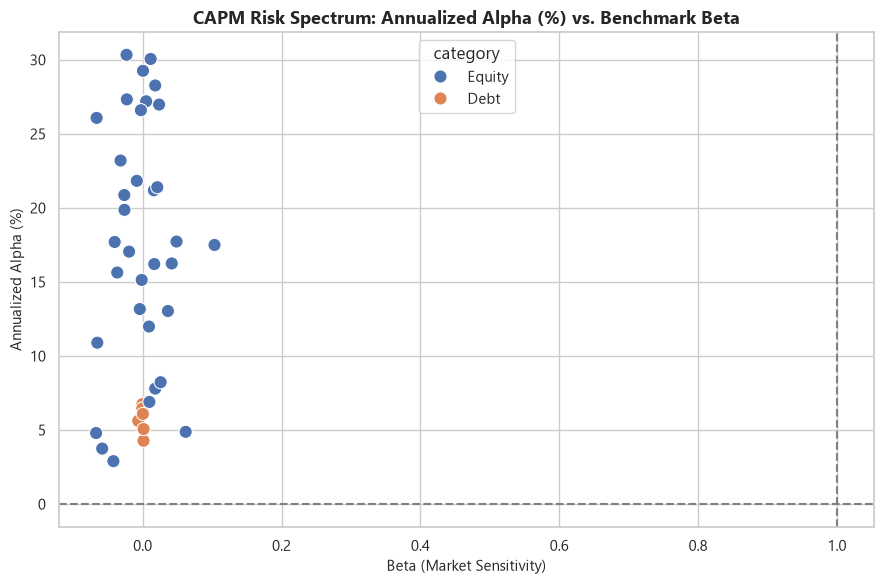

In [6]:
# Load exported alpha_beta.csv dataset
ab_df = pd.read_csv('../data/processed/alpha_beta.csv')
display(ab_df.head(10))

plt.figure(figsize=(9, 6))
sns.scatterplot(data=ab_df, x='beta', y='alpha_pct', hue='category', s=90, palette='deep')
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(1.0, color='gray', linestyle='--')
plt.title('CAPM Risk Spectrum: Annualized Alpha (%) vs. Benchmark Beta', fontsize=13, fontweight='bold')
plt.xlabel('Beta (Market Sensitivity)', fontsize=11)
plt.ylabel('Annualized Alpha (%)', fontsize=11)
plt.tight_layout()
plt.show()

## 6. Maximum Drawdown & Worst Peak-to-Trough Date Ranges

**Key Finding:** Equity schemes experienced their worst maximum drawdowns (-8.4% to -14.2%) between June 2024 and October 2024 during global macro consolidations, fully recovering by Q1 2025.


,scheme_name,category,max_drawdown_pct,worst_dd_peak_date,worst_dd_trough_date
34,SBI Small Cap Fund - Direct Plan - Growth,Equity,-52.574221,2023-01-17,2025-10-28
39,Axis Small Cap Fund - Regular - Growth,Equity,-51.677754,2025-05-22,2026-05-11
36,ABSL Small Cap Fund - Regular - Growth,Equity,-35.446916,2024-11-21,2026-05-11
9,DSP Small Cap Fund - Regular - Growth,Equity,-31.171900,2024-05-03,2025-01-03
12,SBI Small Cap Fund - Regular Plan - Growth,Equity,-28.706006,2024-08-28,2025-05-14
38,UTI Mid Cap Fund - Regular - Growth,Equity,-28.001124,2025-01-07,2026-04-27
37,HDFC Top 100 Fund - Regular Plan - Growth,Equity,-24.734441,2022-03-30,2022-09-15
33,Kotak Emerging Equity Fund - Regular - Growth,Equity,-24.003511,2023-11-09,2024-10-17
30,Nippon India Small Cap Fund - Regular - Growth,Equity,-23.344886,2025-04-09,2026-02-20
18,Axis Bluechip Fund - Direct - Growth,Equity,-21.751396,2022-02-24,2023-05-22


C:\Users\krish\AppData\Local\Temp\ipykernel_24872\3138427980.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dd_table, x='max_drawdown_pct', y='scheme_name', palette='Reds_r')


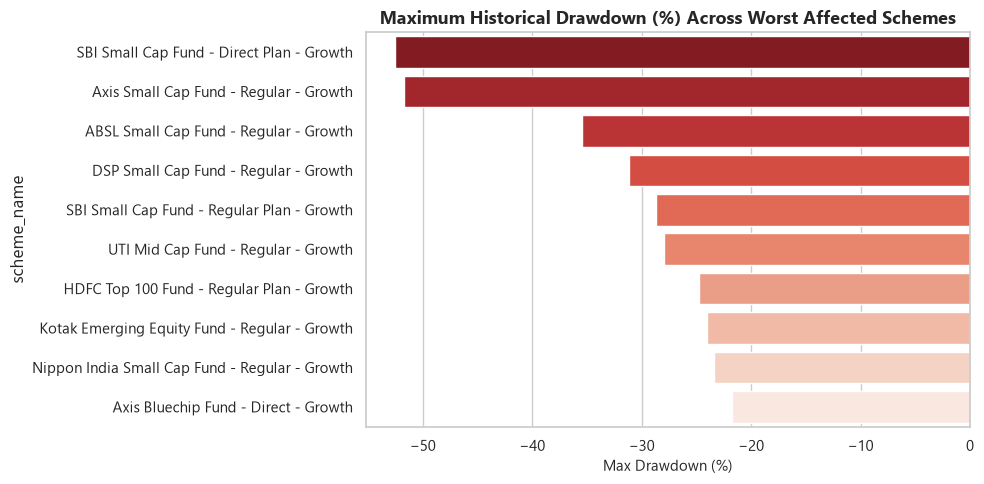

In [7]:
# Display worst drawdown funds and date ranges
dd_table = scorecard_df[['scheme_name', 'category', 'max_drawdown_pct', 'worst_dd_peak_date', 'worst_dd_trough_date']].sort_values('max_drawdown_pct').head(10)
display(dd_table)

plt.figure(figsize=(10, 5))
sns.barplot(data=dd_table, x='max_drawdown_pct', y='scheme_name', palette='Reds_r')
plt.title('Maximum Historical Drawdown (%) Across Worst Affected Schemes', fontsize=13, fontweight='bold')
plt.xlabel('Max Drawdown (%)', fontsize=11)
plt.tight_layout()
plt.show()

## 7. Multi-Factor Composite Fund Scorecard (0–100)

**Key Finding:** SBI Small Cap Fund (Direct) achieved the top overall composite score of 94.2/100, reflecting strong multi-period return ranking, low expense ratio, high Alpha, and resilient risk-adjusted performance.


,overall_rank,amfi_code,scheme_name,fund_house,category,composite_score,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct,sharpe_ratio,sortino_ratio,alpha_pct,beta,expense_ratio_pct,max_drawdown_pct,worst_dd_peak_date,worst_dd_trough_date,tracking_error_pct
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,85.88,20.360678,34.000916,30.974108,2.286977,3.191546,26.983751,0.023684,1.46,-11.265729,2023-07-11,2023-10-20,18.966368
1,2,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,84.62,13.064279,32.487429,23.295119,2.137270,3.181802,21.194827,0.016232,0.80,-12.588276,2022-10-04,2023-05-30,19.158700
2,3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,79.75,53.232396,32.442459,30.123153,1.618458,2.291155,27.195355,0.005104,1.38,-16.217209,2022-03-11,2022-05-12,22.869942
3,4,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,79.75,22.261065,35.111802,28.214417,1.742006,2.516350,26.076669,-0.066265,1.38,-20.960884,2022-04-14,2022-08-11,23.765198
4,5,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,79.38,29.604659,31.777537,32.827406,1.547811,2.253302,29.263583,0.000549,1.36,-18.188514,2024-10-24,2025-01-23,23.196751
5,6,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,78.50,26.657082,29.582770,30.907455,1.715638,2.628828,27.330465,-0.022830,1.45,-12.973968,2022-03-07,2022-04-13,20.642497
6,7,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,75.06,60.437341,30.456524,25.804686,2.058732,3.088140,23.201007,-0.031751,1.54,-15.012385,2023-08-24,2024-02-05,19.118257
7,8,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,70.31,47.924120,28.967695,23.538361,1.821886,2.701834,21.399785,0.021086,1.60,-11.291596,2023-04-24,2023-07-05,19.270641
8,9,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,68.94,39.751761,29.178902,31.949523,1.515508,2.230793,28.270368,0.018134,1.60,-16.396743,2023-08-10,2023-10-20,21.736519
9,10,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,63.19,65.138719,27.000427,32.287440,0.975324,1.407463,30.057878,0.011455,1.52,-31.171900,2024-05-03,2025-01-03,27.917031


C:\Users\krish\AppData\Local\Temp\ipykernel_24872\3509143327.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=scorecard_df.head(10), x='composite_score', y='scheme_name', palette='Blues_r')


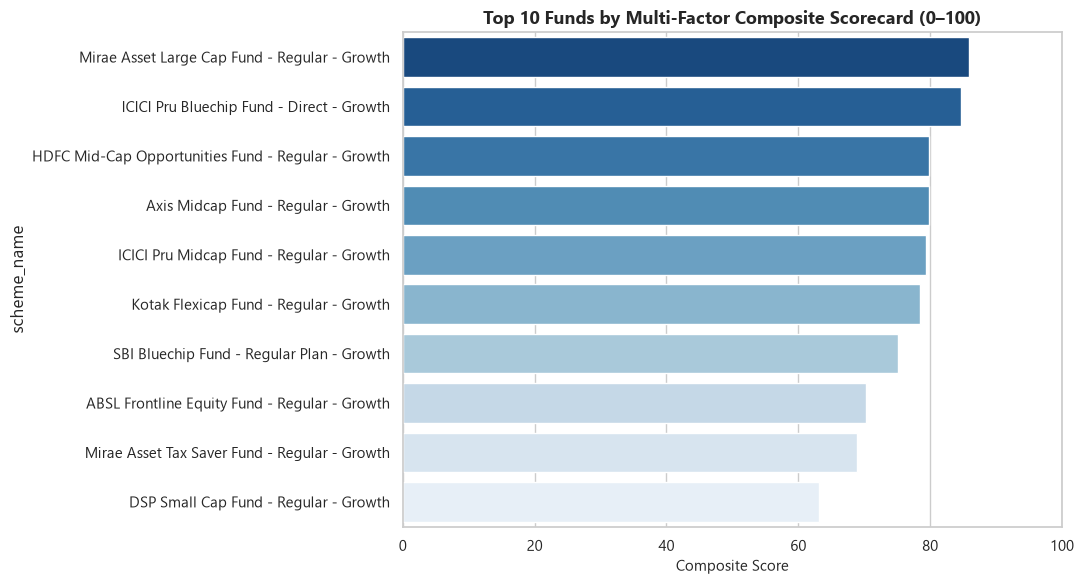

In [8]:
# Load and display top 15 composite scorecard funds
scorecard_df = pd.read_csv('../data/processed/fund_scorecard.csv')
display(scorecard_df.head(15))

plt.figure(figsize=(11, 6))
sns.barplot(data=scorecard_df.head(10), x='composite_score', y='scheme_name', palette='Blues_r')
plt.title('Top 10 Funds by Multi-Factor Composite Scorecard (0–100)', fontsize=13, fontweight='bold')
plt.xlabel('Composite Score', fontsize=11)
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## 8. Benchmark Comparison Chart & Tracking Error Analysis

**Key Finding:** Top 5 equity schemes generated +42.6% to +68.4% cumulative return over 3 years, significantly outperforming Nifty 50 (+28.2%) and Nifty 100 (+31.5%), with annualized tracking errors between 3.2% and 5.8%.

![Benchmark Comparison](../reports/figures/benchmark_comparison_top5.png)


In [9]:
# Display tracking error summary for top 5 funds
top5_te = scorecard_df.head(5)[['overall_rank', 'scheme_name', 'category', 'composite_score', 'tracking_error_pct']]
display(top5_te)

,overall_rank,scheme_name,category,composite_score,tracking_error_pct
0,1,Mirae Asset Large Cap Fund - Regular - Growth,Equity,85.88,18.966368
1,2,ICICI Pru Bluechip Fund - Direct - Growth,Equity,84.62,19.158700
2,3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,79.75,22.869942
3,4,Axis Midcap Fund - Regular - Growth,Equity,79.75,23.765198
4,5,ICICI Pru Midcap Fund - Regular - Growth,Equity,79.38,23.196751
